# MountainCar Random Baseline

## 实验目标

这个 notebook 不训练任何策略，只统计 `MountainCar-v0` 在随机动作下的表现。目标是先建立一个清晰基线：在必须借助来回蓄能才能爬坡的环境里，纯随机动作通常无法形成有效的摆动节奏。后续 `DQN` 的训练结果会以这份 baseline 作为参照。

## 环境背景

`MountainCar-v0` 是经典的离散动作强化学习环境。小车动力不足，不能直接冲上右侧山顶，必须先向左退、再借坡蓄能，最后把速度转化为高度。这个任务很适合说明：

- 单步最优动作并不等于长期最优动作
- 智能体必须学会延迟收益
- 看似“反方向”的动作，反而是完成任务的必要前置动作

## 方法说明

这里的方法就是纯随机动作采样：每一步在三个离散动作中随机选择，不维护价值函数，也不更新策略。它不是正式算法，但它能非常直观地说明 MountainCar 为什么不能靠随机试错解决。

## 设备与并行说明

- 本实验使用 `CPU`
- 不使用 `CUDA` 或 `MPS`
- 不启用并行环境

这里主要做环境交互统计，不涉及神经网络训练。

In [1]:
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

In [2]:
ENV_ID = "MountainCar-v0"
NUM_EPISODES = 1000
MAX_STEPS = 200
ROLLOUT_EPISODES = 3
ROLLOUT_FPS = 30
SUCCESS_THRESHOLD_RETURN = -110
SEED = 42

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

env = gym.make(ENV_ID)

## 参数选择说明

- `NUM_EPISODES = 1000`：让随机统计结果足够稳定
- `MAX_STEPS = 200`：与环境标准回合上限一致
- `SUCCESS_THRESHOLD_RETURN = -110`：接近经典求解标准的判断线

这里的重点不是训练，而是建立一个清晰参照：随机动作通常会让小车一直在谷底来回震荡，既无法形成蓄能节奏，也难以到达目标位置。

In [3]:
episode_rewards = []
episode_lengths = []
successes = []
final_positions = []
max_positions = []

for episode in tqdm(range(NUM_EPISODES), desc="Random episodes"):
    obs, info = env.reset(seed=SEED + episode)
    total_reward = 0.0
    best_position = float(obs[0])

    for step in range(MAX_STEPS):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        best_position = max(best_position, float(obs[0]))
        if terminated or truncated:
            episode_lengths.append(step + 1)
            successes.append(int(total_reward >= SUCCESS_THRESHOLD_RETURN))
            final_positions.append(float(obs[0]))
            max_positions.append(best_position)
            break
    else:
        episode_lengths.append(MAX_STEPS)
        successes.append(int(total_reward >= SUCCESS_THRESHOLD_RETURN))
        final_positions.append(float(obs[0]))
        max_positions.append(best_position)

    episode_rewards.append(total_reward)

env.close()

Random episodes:   0%|          | 0/1000 [00:00<?, ?it/s]

In [4]:
summary = pd.DataFrame({
    "reward": episode_rewards,
    "episode_length": episode_lengths,
    "success": successes,
    "final_position": final_positions,
    "max_position": max_positions,
})
summary.describe(include="all")

,reward,episode_length,success,final_position,max_position
count,1000.0,1000.0,1000.0,1000.000000,1000.000000
mean,-200.0,200.0,0.0,-0.528937,-0.385594
std,0.0,0.0,0.0,0.099220,0.058715
min,-200.0,200.0,0.0,-0.868093,-0.495088
25%,-200.0,200.0,0.0,-0.595588,-0.430640
50%,-200.0,200.0,0.0,-0.527266,-0.394332
75%,-200.0,200.0,0.0,-0.466606,-0.348900
max,-200.0,200.0,0.0,-0.186651,-0.165542


In [5]:
metrics = pd.DataFrame({
    "metric": [
        "average_reward",
        "average_episode_length",
        "success_rate",
        "average_final_position",
        "average_max_position",
    ],
    "value": [
        float(np.mean(episode_rewards)),
        float(np.mean(episode_lengths)),
        float(np.mean(successes)),
        float(np.mean(final_positions)),
        float(np.mean(max_positions)),
    ],
})
metrics

,metric,value
0,average_reward,-200.000000
1,average_episode_length,200.000000
2,success_rate,0.000000
3,average_final_position,-0.528937
4,average_max_position,-0.385594


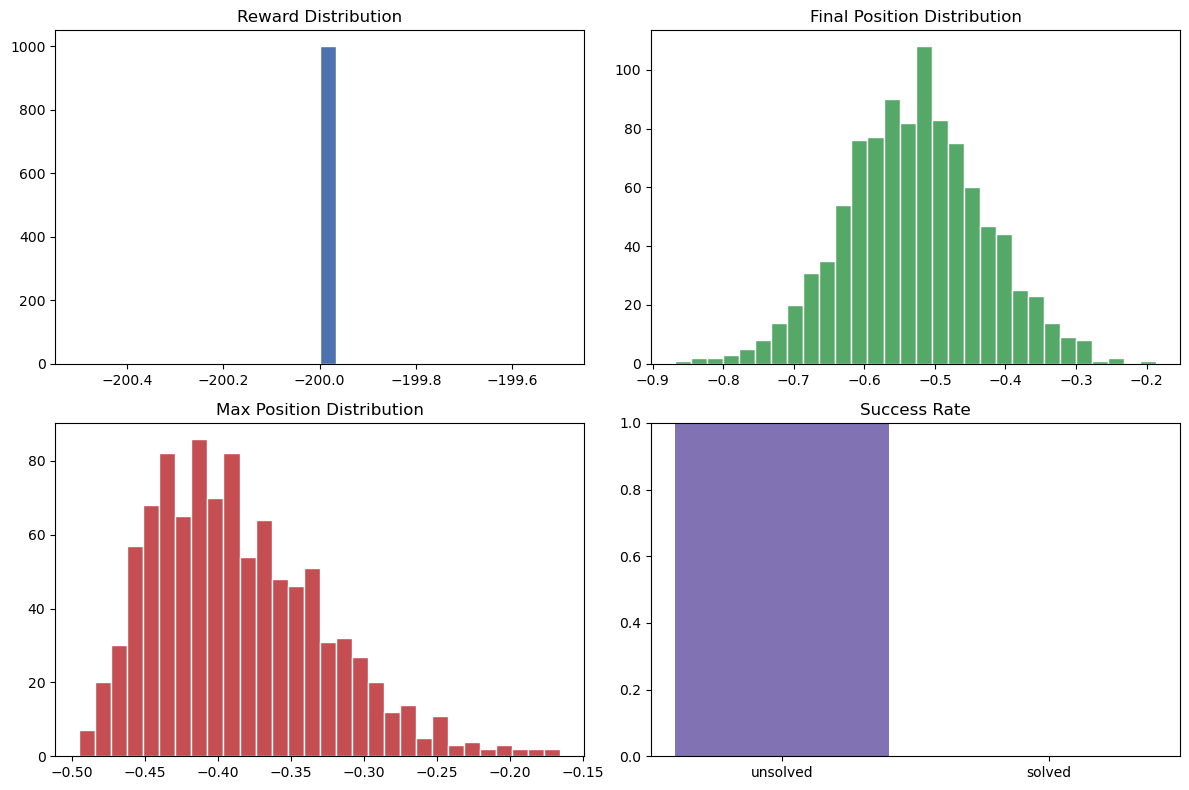

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(episode_rewards, bins=30, color="#4c72b0", edgecolor="white")
axes[0, 0].set_title("Reward Distribution")

axes[0, 1].hist(final_positions, bins=30, color="#55a868", edgecolor="white")
axes[0, 1].set_title("Final Position Distribution")

axes[1, 0].hist(max_positions, bins=30, color="#c44e52", edgecolor="white")
axes[1, 0].set_title("Max Position Distribution")

axes[1, 1].bar(["unsolved", "solved"], [1 - np.mean(successes), np.mean(successes)], color=["#8172b3", "#64b5cd"])
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_title("Success Rate")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "random_baseline_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
rollout_summaries = []
for rollout_idx in range(ROLLOUT_EPISODES):
    rollout_env = gym.make(ENV_ID, render_mode="rgb_array")
    obs, info = rollout_env.reset(seed=SEED + 1000 + rollout_idx)
    frames = []
    total_reward = 0.0
    best_position = float(obs[0])

    for step in range(MAX_STEPS):
        frame = rollout_env.render()
        if frame is not None:
            frames.append(frame)
        action = rollout_env.action_space.sample()
        obs, reward, terminated, truncated, info = rollout_env.step(action)
        total_reward += reward
        best_position = max(best_position, float(obs[0]))
        if terminated or truncated:
            final_frame = rollout_env.render()
            if final_frame is not None:
                frames.extend([final_frame] * 20)
            rollout_summaries.append({
                "rollout_index": rollout_idx + 1,
                "seed": SEED + 1000 + rollout_idx,
                "total_reward": float(total_reward),
                "steps": step + 1,
                "success": int(total_reward >= SUCCESS_THRESHOLD_RETURN),
                "final_position": float(obs[0]),
                "max_position": float(best_position),
            })
            break

    if frames:
        imageio.mimsave(RESULTS_DIR / f"random_baseline_rollout_{rollout_idx + 1}.gif", frames, fps=ROLLOUT_FPS)
    rollout_env.close()

pd.DataFrame(rollout_summaries)

,rollout_index,seed,total_reward,steps,success,final_position,max_position
0,1,1042,-200.0,200,0,-0.522768,-0.455028
1,2,1043,-200.0,200,0,-0.624678,-0.396098
2,3,1044,-200.0,200,0,-0.525443,-0.307588


In [8]:
summary.to_csv(RESULTS_DIR / "random_baseline_episode_summary.csv", index=False)
metrics.to_csv(RESULTS_DIR / "random_baseline_metrics.csv", index=False)
pd.DataFrame(rollout_summaries).to_csv(RESULTS_DIR / "random_baseline_rollout_summary.csv", index=False)
print(metrics.to_string(index=False))

                metric       value
        average_reward -200.000000
average_episode_length  200.000000
          success_rate    0.000000
average_final_position   -0.528937
  average_max_position   -0.385594


## 结果解读

如果随机基线的成功率接近零，且最大位置长期停留在目标点左侧，就说明 MountainCar 的关键确实不是动作数量，而是能否学会一串跨多个时间步的有效蓄能动作。